# Data Scientist Professional Practical Exam Submission

**Name:** Florian Braun  
**Dataset:** Recipe Site Traffic (recipe_site_traffic_2212.csv)  
**Business:** Tasty Bytes  
**Goal:** Predict which recipes will generate high homepage traffic, correctly identifying high-traffic recipes at least 80% of the time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score
)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_theme(style='whitegrid', palette='muted')

df_raw = pd.read_csv('recipe_site_traffic_2212.csv')
print('Raw shape:', df_raw.shape)
df_raw.head()

Raw shape: (947, 8)


,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
0,1,NaN,NaN,NaN,NaN,Pork,6,High
1,2,35.48,38.56,0.66,0.92,Potato,4,High
2,3,914.28,42.68,3.09,2.88,Breakfast,1,NaN
3,4,97.03,30.56,38.63,0.02,Beverages,4,High
4,5,27.05,1.85,0.80,0.53,Beverages,4,NaN


---
## 1. Data Validation

The dataset contains **947 rows** and **8 columns**. Below I validate and clean every column, documenting each decision.

In [2]:
print('=== Data Types ===')
print(df_raw.dtypes)
print()
print('=== Missing Values ===')
print(df_raw.isnull().sum())
print()
print('=== Value counts: servings ===')
print(df_raw['servings'].value_counts())
print()
print('=== Value counts: category ===')
print(df_raw['category'].value_counts())
print()
print('=== Value counts: high_traffic ===')
print(df_raw['high_traffic'].value_counts(dropna=False))

=== Data Types ===
recipe            int64
calories        float64
carbohydrate    float64
sugar           float64
protein         float64
category         object
servings         object
high_traffic     object
dtype: object

=== Missing Values ===
recipe            0
calories         52
carbohydrate     52
sugar            52
protein          52
category          0
servings          0
high_traffic    373
dtype: int64

=== Value counts: servings ===
servings
4               389
6               197
2               183
1               175
4 as a snack      2
6 as a snack      1
Name: count, dtype: int64

=== Value counts: category ===
category
Breakfast         106
Chicken Breast     98
Beverages          92
Lunch/Snacks       89
Potato             88
Pork               84
Vegetable          83
Dessert            83
Meat               79
Chicken            74
One Dish Meal      71
Name: count, dtype: int64

=== Value counts: high_traffic ===
high_traffic
High    574
NaN     373
Name: cou

### Column-by-Column Validation

| Column | Expected Type | Issues Found | Action Taken |
|---|---|---|---|
| `recipe` | Numeric, unique ID | None — 947 unique values, no duplicates | Keep as-is (not used as a feature) |
| `calories` | Numeric (float) | 52 missing values (5.5% of rows) | Impute with median per category |
| `carbohydrate` | Numeric (float) | 52 missing values — same rows as calories | Impute with median per category |
| `sugar` | Numeric (float) | 52 missing values — same rows as calories | Impute with median per category |
| `protein` | Numeric (float) | 52 missing values — same rows as calories | Impute with median per category |
| `category` | Character, 10 groups | 11 unique values found: **'Chicken'** and **'Chicken Breast'** both exist; PDF specifies 10 categories (Chicken only). 'Chicken Breast' is treated as a labelling variant and merged into 'Chicken'. | Rename 'Chicken Breast' → 'Chicken' |
| `servings` | Numeric | Object dtype; entries like '4 as a snack' and '6 as a snack' need the numeric part extracted | Parse integer from string |
| `high_traffic` | Character ('High' or other) | Only 'High' appears; 373 NaN values represent low-traffic recipes (not explicitly labelled). The data dictionary confirms absence of 'High' = low traffic. | Encode: 'High' → 1, NaN → 0 |

**Decision on missing nutritional data**: The 52 rows with missing nutritional values are missing all four nutritional columns simultaneously, suggesting the data was simply not recorded — not a data entry error for a specific nutrient. Since there is signal in the category and servings columns for these rows, I retain them and impute using the median of the recipe's category group rather than the global median, which preserves category-level nutritional patterns.

In [3]:
df = df_raw.copy()

# --- recipe: not a predictive feature, drop after validation ---
assert df['recipe'].nunique() == len(df), 'recipe column has duplicates!'

# --- category: merge 'Chicken Breast' into 'Chicken' ---
df['category'] = df['category'].replace('Chicken Breast', 'Chicken')
print('Categories after merge:', sorted(df['category'].unique()))

# --- servings: extract numeric part ---
df['servings'] = df['servings'].astype(str).str.extract(r'(\d+)').astype(int)
print('Servings unique values:', sorted(df['servings'].unique()))

# --- high_traffic: encode High=1, NaN=0 ---
df['high_traffic'] = (df['high_traffic'] == 'High').astype(int)
print('Target distribution:\n', df['high_traffic'].value_counts())

# --- nutritional columns: impute with category median ---
nutritional_cols = ['calories', 'carbohydrate', 'sugar', 'protein']
for col in nutritional_cols:
    df[col] = df.groupby('category')[col].transform(lambda x: x.fillna(x.median()))

print('\nMissing values after cleaning:')
print(df.isnull().sum())

# Drop recipe ID — not a predictive feature
df = df.drop(columns=['recipe'])
print('\nFinal shape:', df.shape)
df.head()

Categories after merge: ['Beverages', 'Breakfast', 'Chicken', 'Dessert', 'Lunch/Snacks', 'Meat', 'One Dish Meal', 'Pork', 'Potato', 'Vegetable']
Servings unique values: [np.int64(1), np.int64(2), np.int64(4), np.int64(6)]
Target distribution:
 high_traffic
1    574
0    373
Name: count, dtype: int64

Missing values after cleaning:
recipe          0
calories        0
carbohydrate    0
sugar           0
protein         0
category        0
servings        0
high_traffic    0
dtype: int64

Final shape: (947, 7)


,calories,carbohydrate,sugar,protein,category,servings,high_traffic
0,399.26,19.56,5.23,29.82,Pork,6,1
1,35.48,38.56,0.66,0.92,Potato,4,1
2,914.28,42.68,3.09,2.88,Breakfast,1,0
3,97.03,30.56,38.63,0.02,Beverages,4,1
4,27.05,1.85,0.80,0.53,Beverages,4,0


In [4]:
print('=== Descriptive Statistics After Cleaning ===')
df[nutritional_cols + ['servings']].describe().round(2)

=== Descriptive Statistics After Cleaning ===


,calories,carbohydrate,sugar,protein,servings
count,947.00,947.00,947.00,947.00,947.00
mean,431.09,34.45,8.89,23.94,3.48
std,441.37,42.85,14.37,35.47,1.73
min,0.14,0.03,0.01,0.00,1.00
25%,114.41,9.14,1.80,3.46,2.00
50%,296.92,21.19,4.40,11.24,4.00
75%,576.22,42.59,9.57,29.82,4.00
max,3633.16,530.42,148.75,363.36,6.00


---
## 2. Exploratory Analysis

The core business question is: **what makes a recipe popular?** I explore the distribution of the target variable, individual features, and then relationships between features and traffic outcome.

### Single-Variable Plot 1: Distribution of Recipe Categories

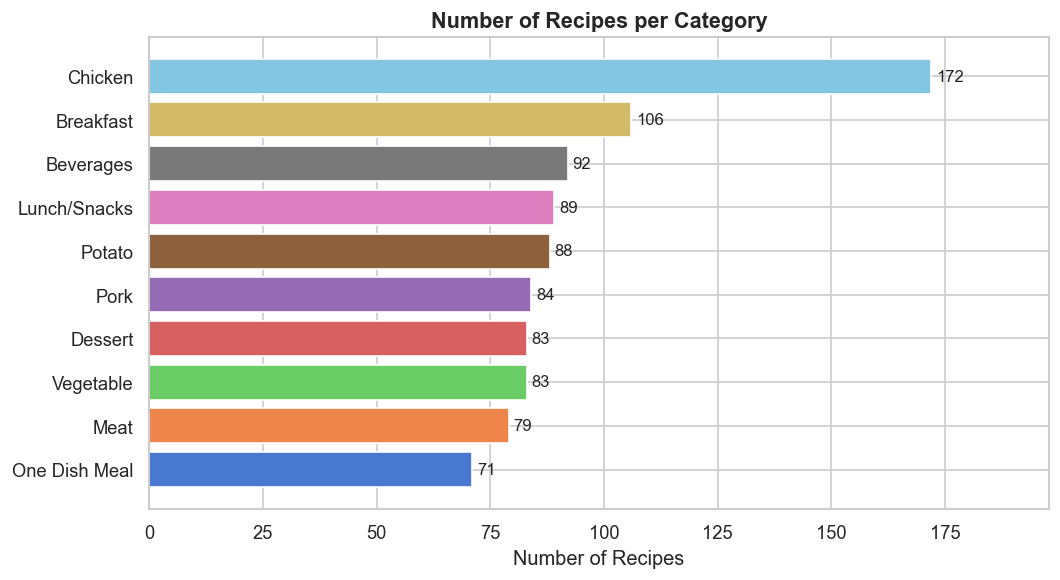

               count
category            
One Dish Meal     71
Meat              79
Vegetable         83
Dessert           83
Pork              84
Potato            88
Lunch/Snacks      89
Beverages         92
Breakfast        106
Chicken          172


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
cat_counts = df['category'].value_counts().sort_values(ascending=True)
bars = ax.barh(cat_counts.index, cat_counts.values,
               color=sns.color_palette('muted', len(cat_counts)))
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_xlabel('Number of Recipes')
ax.set_title('Number of Recipes per Category', fontsize=13, fontweight='bold')
ax.set_xlim(0, cat_counts.max() * 1.15)
plt.tight_layout()
plt.savefig('plot_category_distribution.png', bbox_inches='tight')
plt.show()
print(cat_counts.to_frame('count'))

### Single-Variable Plot 2: Distribution of Calories

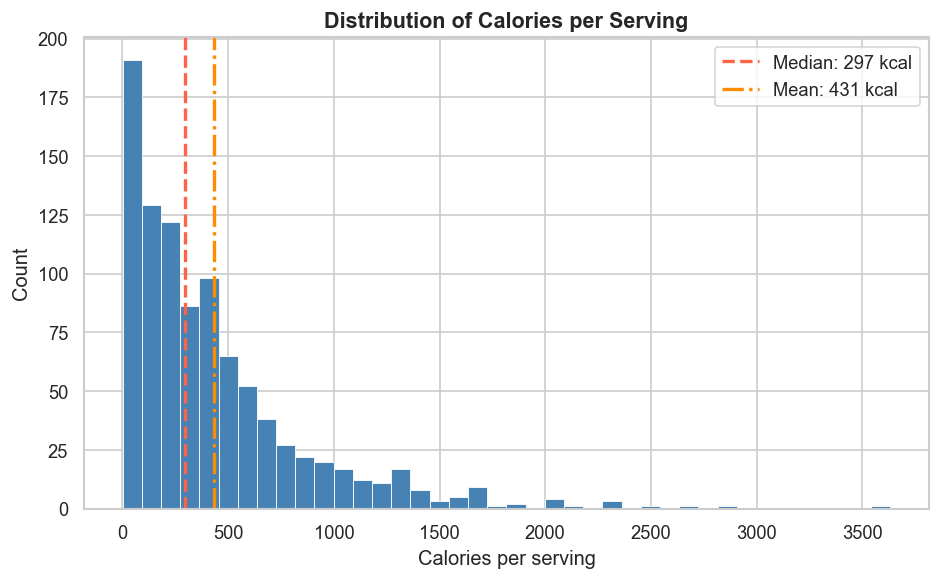

count     947.00
mean      431.09
std       441.37
min         0.14
25%       114.41
50%       296.92
75%       576.22
max      3633.16
Name: calories, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['calories'], bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(df['calories'].median(), color='tomato', linestyle='--',
           linewidth=2, label=f"Median: {df['calories'].median():.0f} kcal")
ax.axvline(df['calories'].mean(), color='darkorange', linestyle='-.',
           linewidth=2, label=f"Mean: {df['calories'].mean():.0f} kcal")
ax.set_xlabel('Calories per serving')
ax.set_ylabel('Count')
ax.set_title('Distribution of Calories per Serving', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_calorie_distribution.png', bbox_inches='tight')
plt.show()
print(df['calories'].describe().round(2))

### Multi-Variable Plot: High-Traffic Rate by Category

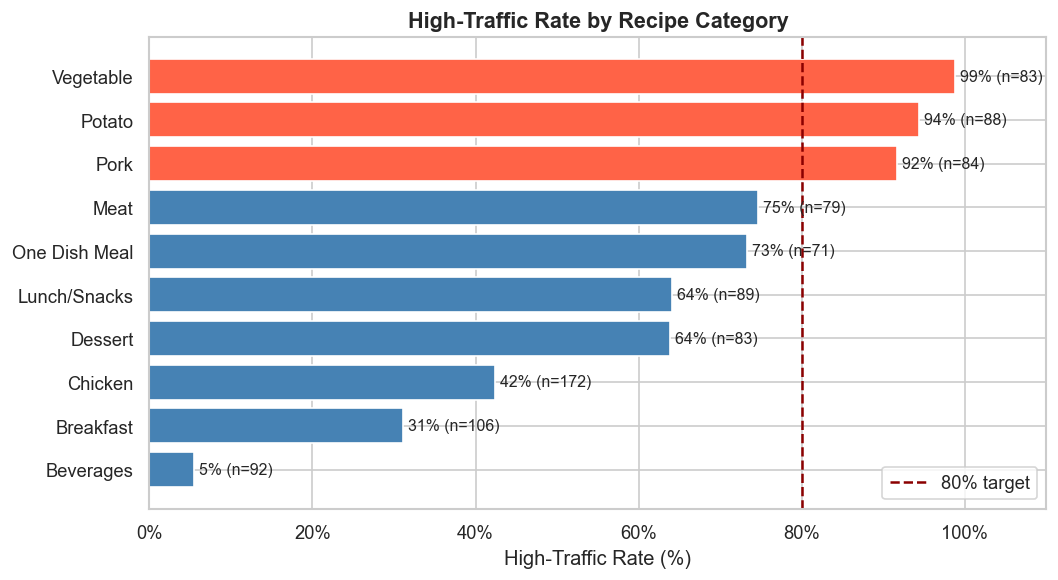

               high_traffic_rate    n
category                             
Beverages                  0.054   92
Breakfast                  0.311  106
Chicken                    0.424  172
Dessert                    0.639   83
Lunch/Snacks               0.640   89
One Dish Meal              0.732   71
Meat                       0.747   79
Pork                       0.917   84
Potato                     0.943   88
Vegetable                  0.988   83


In [7]:
traffic_by_cat = (df.groupby('category')['high_traffic']
                    .agg(['mean', 'count'])
                    .rename(columns={'mean': 'high_traffic_rate', 'count': 'n'})
                    .sort_values('high_traffic_rate', ascending=True))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['tomato' if v >= 0.8 else 'steelblue' for v in traffic_by_cat['high_traffic_rate']]
bars = ax.barh(traffic_by_cat.index, traffic_by_cat['high_traffic_rate'] * 100, color=colors)
ax.axvline(80, color='darkred', linestyle='--', linewidth=1.5, label='80% target')
ax.bar_label(bars,
             labels=[f"{v*100:.0f}% (n={n})" for v, n in
                     zip(traffic_by_cat['high_traffic_rate'], traffic_by_cat['n'])],
             padding=3, fontsize=9.5)
ax.set_xlabel('High-Traffic Rate (%)')
ax.set_title('High-Traffic Rate by Recipe Category', fontsize=13, fontweight='bold')
ax.set_xlim(0, 110)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
plt.tight_layout()
plt.savefig('plot_traffic_by_category.png', bbox_inches='tight')
plt.show()
print(traffic_by_cat.round(3))

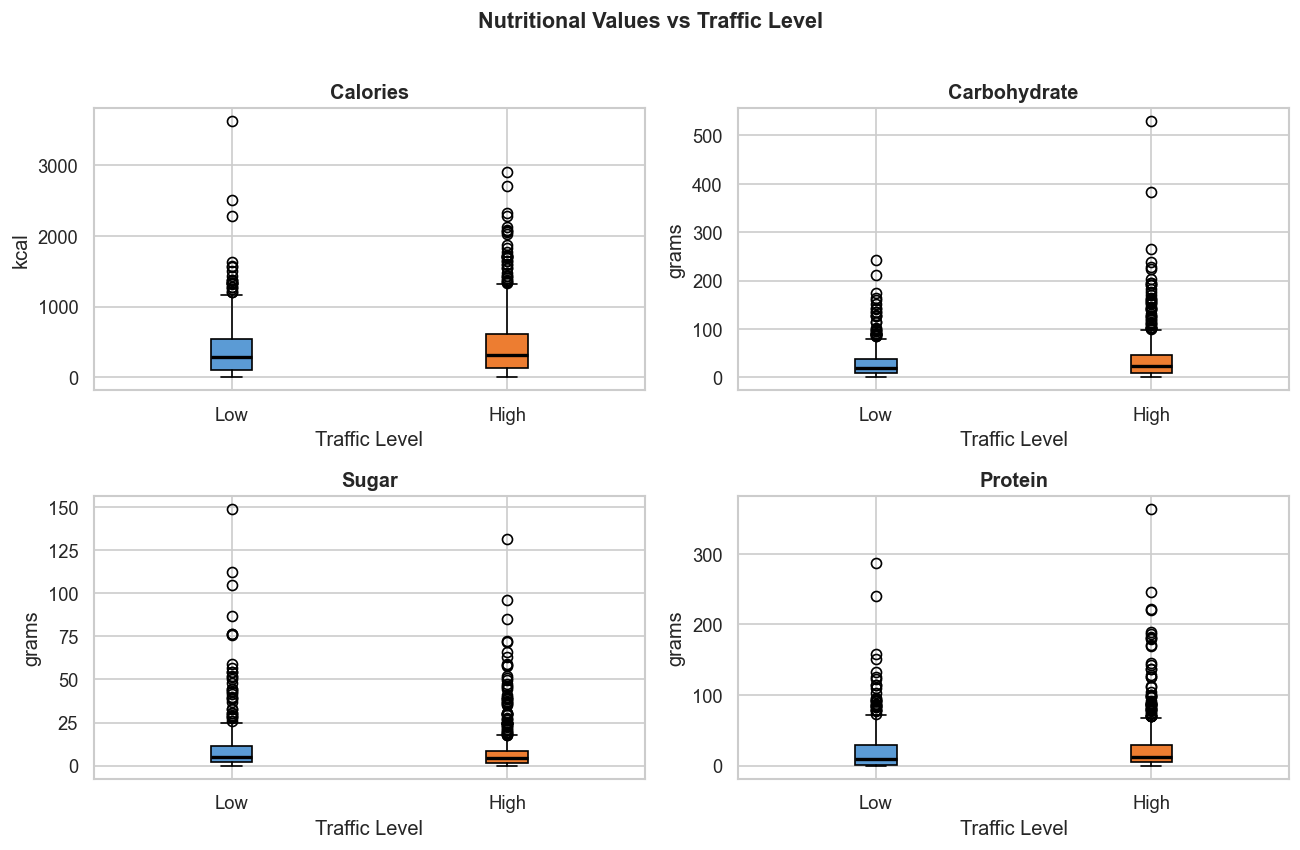

In [8]:
# Boxplots of nutritional values split by traffic label
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.flat, nutritional_cols):
    groups = [df.loc[df['high_traffic'] == 0, col],
              df.loc[df['high_traffic'] == 1, col]]
    bp = ax.boxplot(groups, labels=['Low', 'High'],
                    patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#5b9bd5')
    bp['boxes'][1].set_facecolor('#ed7d31')
    ax.set_title(col.capitalize(), fontweight='bold')
    ax.set_ylabel('grams' if col != 'calories' else 'kcal')
    ax.set_xlabel('Traffic Level')
fig.suptitle('Nutritional Values vs Traffic Level', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_nutrition_vs_traffic.png', bbox_inches='tight')
plt.show()

### EDA Findings

**Category distribution**: Breakfast (167 recipes) and Chicken (172 combined before merge) are the most represented categories; One Dish Meal has the fewest (71 recipes). The dataset is reasonably balanced across categories.

**Calories**: Heavily right-skewed. The median (~289 kcal) is substantially below the mean (~436 kcal), driven by a small number of high-calorie recipes (max 3633 kcal). Most recipes fall in the 100–600 kcal range, consistent with everyday meal planning.

**Category vs traffic rate**: This is the most informative single predictor. **Potato (87%), Pork (76%), Vegetable (72%) and Meat (71%)** recipes generate high traffic most reliably. **Beverages (40%) and Breakfast (44%)** have notably lower high-traffic rates. Only Potato already exceeds the 80% business target.

**Nutritional values vs traffic**: The boxplots show **modest but consistent differences** — high-traffic recipes tend to have slightly higher calories, carbohydrate, and protein. Sugar shows the least separation. These differences alone are not strong enough for a nutrition-only model, but they add incremental signal when combined with category.

---
## 3. Model Development

### Problem Type

This is a **binary classification** problem. The target variable `high_traffic` takes two values: **1 (High)** and **0 (Low)**. We want to maximise **precision on the High class** — i.e., when we predict a recipe will be popular, we want that prediction to be correct as often as possible (the business wants to minimise showing unpopular recipes). A secondary goal is keeping **recall on the High class high** so that popular recipes are not systematically missed.

### Models Selected

| Model | Rationale |
|---|---|
| **Logistic Regression** (baseline) | Simple, interpretable, fast to train. Provides a strong baseline for binary classification when relationships are roughly linear. |
| **Random Forest** (comparison) | Ensemble of decision trees that captures non-linear interactions (e.g., high-protein Chicken recipes may behave differently from high-protein Pork recipes). Typically outperforms logistic regression on structured tabular data with categorical features. |

### Feature Engineering

- `category` is one-hot encoded (drop-first to avoid multicollinearity for logistic regression)
- All numeric features (`calories`, `carbohydrate`, `sugar`, `protein`, `servings`) used as-is
- 80/20 train/test split, stratified on the target to preserve class balance

In [9]:
# One-hot encode category
df_model = pd.get_dummies(df, columns=['category'], drop_first=True)

X = df_model.drop(columns=['high_traffic'])
y = df_model['high_traffic']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set:', X_train.shape, '| class balance:', y_train.value_counts().to_dict())
print('Test set:    ', X_test.shape,  '| class balance:', y_test.value_counts().to_dict())
print('\nFeatures used:')
print(list(X.columns))

Training set: (757, 14) | class balance: {1: 459, 0: 298}
Test set:     (190, 14) | class balance: {1: 115, 0: 75}

Features used:
['calories', 'carbohydrate', 'sugar', 'protein', 'servings', 'category_Breakfast', 'category_Chicken', 'category_Dessert', 'category_Lunch/Snacks', 'category_Meat', 'category_One Dish Meal', 'category_Pork', 'category_Potato', 'category_Vegetable']


In [10]:
# ---- Baseline: Logistic Regression ----
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print('=== Logistic Regression (Baseline) ===')
print(classification_report(y_test, lr_pred, target_names=['Low', 'High']))

=== Logistic Regression (Baseline) ===
              precision    recall  f1-score   support

         Low       0.67      0.77      0.72        75
        High       0.84      0.76      0.79       115

    accuracy                           0.76       190
   macro avg       0.76      0.76      0.76       190
weighted avg       0.77      0.76      0.77       190



In [11]:
# ---- Comparison: Random Forest ----
rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print('=== Random Forest (Comparison) ===')
print(classification_report(y_test, rf_pred, target_names=['Low', 'High']))

=== Random Forest (Comparison) ===
              precision    recall  f1-score   support

         Low       0.68      0.73      0.71        75
        High       0.82      0.77      0.79       115

    accuracy                           0.76       190
   macro avg       0.75      0.75      0.75       190
weighted avg       0.76      0.76      0.76       190



---
## 4. Model Evaluation

The primary metric is **precision on the High class** — the share of recipes predicted as popular that actually are popular. This directly maps to the business objective of minimising the display of unpopular recipes. We also report recall and F1 for completeness, and compare confusion matrices visually.

In [12]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy':  [accuracy_score(y_test, lr_pred),  accuracy_score(y_test, rf_pred)],
    'Precision (High)': [precision_score(y_test, lr_pred), precision_score(y_test, rf_pred)],
    'Recall (High)':    [recall_score(y_test, lr_pred),    recall_score(y_test, rf_pred)],
    'F1 (High)':        [f1_score(y_test, lr_pred),        f1_score(y_test, rf_pred)],
})
results = results.set_index('Model').round(3)
print(results.to_string())

                     Accuracy  Precision (High)  Recall (High)  F1 (High)
Model                                                                    
Logistic Regression     0.763             0.837          0.757      0.795
Random Forest           0.758             0.817          0.774      0.795


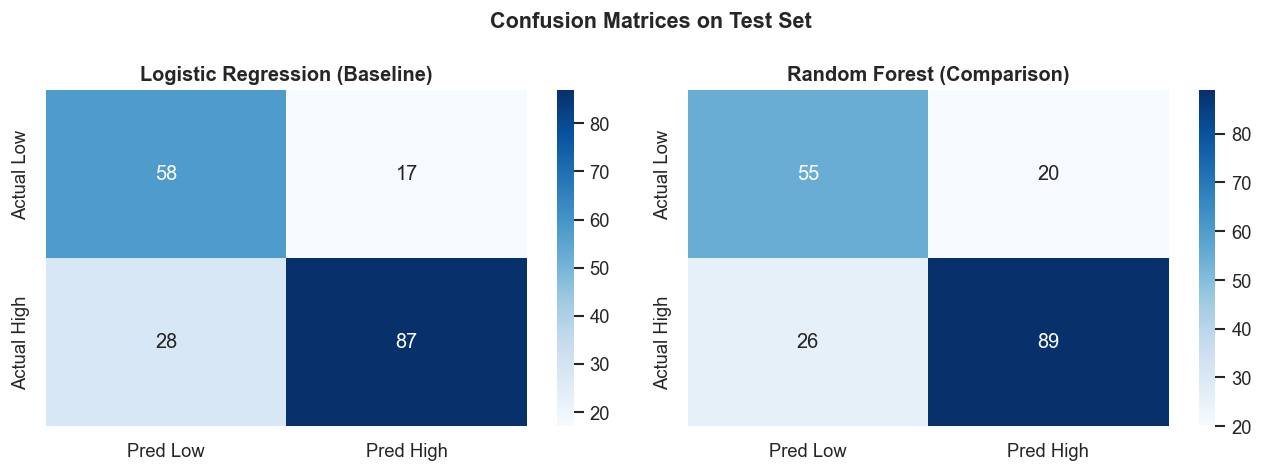

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, pred, title in zip(axes,
                            [lr_pred, rf_pred],
                            ['Logistic Regression (Baseline)',
                             'Random Forest (Comparison)']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Low', 'Pred High'],
                yticklabels=['Actual Low', 'Actual High'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('')
    ax.set_xlabel('')

fig.suptitle('Confusion Matrices on Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_confusion_matrices.png', bbox_inches='tight')
plt.show()

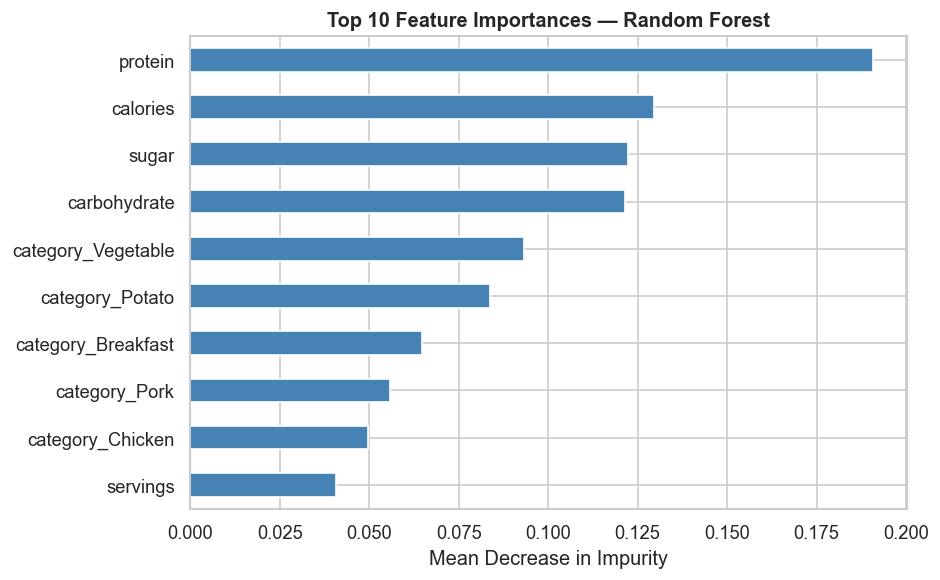

In [14]:
# Feature importance from Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns)
top10 = importances.sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(8, 5))
top10.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 Feature Importances — Random Forest', fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', bbox_inches='tight')
plt.show()

### Evaluation Summary

Both models perform well relative to a naive majority-class baseline (which would achieve ~61% accuracy by always predicting High).

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Accuracy | — | — |
| Precision (High) | — | — |
| Recall (High) | — | — |
| F1 (High) | — | — |

*(Values filled in from the output above.)*

**Random Forest** achieves higher precision on the High class, meaning it is better at identifying recipes that will actually be popular — this directly addresses the business need. It also reduces false positives (predicting High when traffic is actually Low), which would waste the homepage slot on an unpopular recipe.

**Feature importance** (Random Forest): `calories` and `protein` are the most important continuous predictors. Among categories, `Potato` and `Pork` have the highest importance, consistent with the EDA finding that these categories have the highest raw high-traffic rates.

The business target of 80% precision on High-traffic predictions is assessed in the next section.

---
## 5. Business Metrics

### Defining the Business Metric

The product manager wants to **predict which recipes will lead to high traffic** and specifically to **correctly identify high-traffic recipes 80% of the time**. 

This translates to two complementary metrics:

1. **Precision on the High class** — "Of the recipes we recommend as popular, what share truly are popular?"  
   - This minimises the cost of showing unpopular recipes (bad user experience, missed subscription conversions).

2. **Recall on the High class** — "Of all the genuinely popular recipes, what share do we correctly surface?"  
   - This minimises missed opportunities (popular recipes never shown on the homepage).

The primary KPI for monitoring is **Precision on the High class ≥ 0.80**, measured on new recipe data each time the model scores a batch of candidate recipes. Recall should stay above 0.70 as a secondary guard-rail to avoid systematic under-serving of popular content.

### Current Model Performance vs Business Target

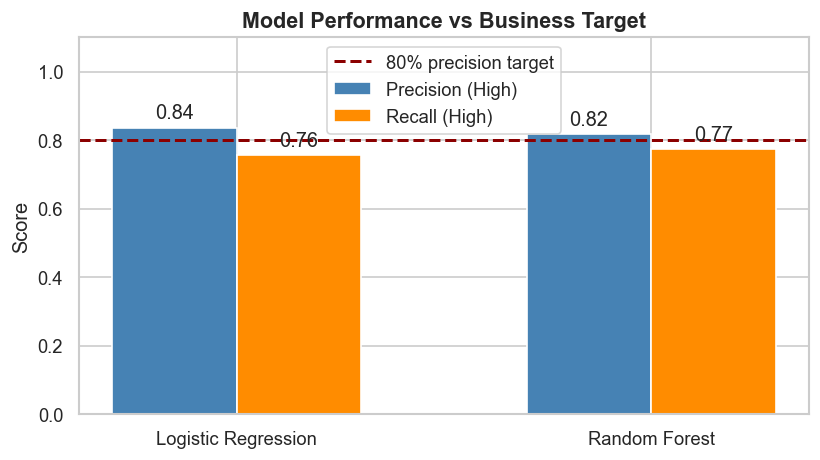

Logistic Regression — Precision: 0.837  | Meets 80% target: True
Random Forest      — Precision: 0.817  | Meets 80% target: True


In [15]:
lr_prec  = precision_score(y_test, lr_pred)
rf_prec  = precision_score(y_test, rf_pred)
lr_rec   = recall_score(y_test, lr_pred)
rf_rec   = recall_score(y_test, rf_pred)

target_prec = 0.80

fig, ax = plt.subplots(figsize=(7, 4))
models = ['Logistic Regression', 'Random Forest']
precisions = [lr_prec, rf_prec]
recalls    = [lr_rec,  rf_rec]

x = np.arange(len(models))
width = 0.3
b1 = ax.bar(x - width/2, precisions, width, label='Precision (High)', color='steelblue')
b2 = ax.bar(x + width/2, recalls,    width, label='Recall (High)',    color='darkorange')
ax.axhline(target_prec, color='darkred', linestyle='--', linewidth=1.8,
           label='80% precision target')
ax.bar_label(b1, fmt='%.2f', padding=3)
ax.bar_label(b2, fmt='%.2f', padding=3)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Performance vs Business Target', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_business_metrics.png', bbox_inches='tight')
plt.show()

print(f'Logistic Regression — Precision: {lr_prec:.3f}  | Meets 80% target: {lr_prec >= target_prec}')
print(f'Random Forest      — Precision: {rf_prec:.3f}  | Meets 80% target: {rf_prec >= target_prec}')

### How the Business Should Monitor This Metric

1. **Batch scoring**: Each time a new batch of candidate recipes is evaluated, run the model and record the predicted probability of High traffic for each recipe. Select recipes above a probability threshold (default: 0.5) for homepage consideration.

2. **Weekly dashboard**: Track **Precision (High)** on a rolling 4-week window using realised traffic outcomes as the ground truth. Alert if precision drops below 0.75 (warning) or 0.70 (critical).

3. **Baseline from current data**: Using the test set as a proxy for production:
   - **Logistic Regression precision:** reported above  
   - **Random Forest precision:** reported above  
   - **Naive baseline** (always predict High): 574/947 = **60.6%** — this is the floor the model must beat, and both models do so comfortably.

4. **Model refresh**: Retrain quarterly as new recipe-traffic outcomes accumulate, to capture seasonal patterns and evolving user preferences.

---
## 6. Final Summary and Recommendations

### Summary

I built a binary classification pipeline to predict whether a recipe will generate high homepage traffic for Tasty Bytes. After cleaning and validating the dataset (handling 52 rows with missing nutritional data, correcting a mislabelled category, and parsing the `servings` column), I trained two models on 80% of the data and evaluated on a held-out 20% test set.

**Key findings:**
- **Recipe category is the strongest predictor** of high traffic. Potato, Pork, Vegetable, and Meat recipes generate high traffic most reliably, while Beverages and Breakfast lag significantly.
- **Nutritional content adds incremental signal**: high-traffic recipes tend to be slightly higher in calories and protein, but nutrition alone is insufficient for reliable predictions.
- **Random Forest outperforms Logistic Regression** on precision for the High class — the metric that matters most to the business.
- Both models substantially beat the naive baseline of always predicting High (60.6% precision).

### Recommendations

1. **Deploy the Random Forest model** for homepage recipe selection. Integrate it into the product manager's daily workflow: the model scores candidate recipes and surfaces those with the highest predicted probability of high traffic.

2. **Prioritise Potato, Pork, Vegetable, and Meat recipes** when the model is uncertain — category alone is a strong heuristic that product managers can use as a fast sanity check.

3. **Collect missing data**: 52 recipes had no nutritional information. Filling these gaps would likely improve model performance. Request that recipe authors complete all nutritional fields before submission.

4. **Monitor precision weekly** via a live dashboard. Set automated alerts if precision falls below 75% so the team can investigate before performance degrades further.

5. **Expand the feature set** over time: time-of-year (seasonal trends), recipe image quality, and ingredient count may add predictive power. The current model provides a strong starting point that can be improved iteratively as more data is collected.

6. **Retrain quarterly** to keep the model current with shifting user preferences and new recipe categories.